# Fit and inspect individual events with LicketyFit

This notebook uses the production `batch_fit_driver.py` engines through `scripts/single_event_fit.py`. It does not contain a second fit implementation. The same event loaders, active-PMT rules, detector geometry, physics switches, seed bank, prompt cuts, likelihood, and optimizer are used here and in `run_wcte.py` / `run_wcsim.py`.

The workflow is: load a small event collection, prepare and plot one event exactly as the likelihood will see it, fit it, then compare PMT-by-PMT observations with the model prediction at the fitted parameters. The WCSim example comes first because it needs only a file path; the WCTE example follows and adds beam selection. The last section walks through the settings you are most likely to change, without running a fit for each one.

Everything you set here has the same name and meaning in the two launchers, so a configuration that works in this notebook can be copied into `scripts/run_wcte.py` or `scripts/run_wcsim.py` line for line.

## 0. What changed, if you have used this notebook before

Two things in the current driver break older notebook cells.

**`fit_mode` is gone.** Seed coverage and endpoint physics are now independent axes, because they were always independent choices:

| `seeding_mode` | `interaction_mode` | what it does | retired `fit_mode` name |
|---|---|---|---|
| `beam` | `full_length` | compact beam-pipe seed bank, one threshold-range endpoint | `full_length`, `beam` |
| `general` | `full_length` | detector-wide seed search, one threshold-range endpoint | `cosmic` |
| `general` | `absorption` | detector-wide search, separate abrupt visible endpoint | `absorption` |
| `beam` | `absorption` | beam-pipe seeds with an abrupt endpoint | had no legacy name |

Passing `fit_mode=` now raises a message naming the replacement pair. `general` is the current name for what used to be called cosmic mode; you will still see `cosmic` as the internal engine label in diagnostics, which is expected.

**WCTE has a new beam PID policy.** `light_particle_pid_mode` defaults to `"act_tof"` and changes which events enter a nominal electron, muon, or pion sample. Section 7b covers it. If you are comparing against results from before v1.45, the event sample itself has changed, not just the fit.

## 1. One-time repository setup

From the repository root, initialize the two direct runtime submodules. Do not use `--recursive`; LicketyFit does not use `analysis_tools`' nested submodules.

```bash
git submodule update --init analysis_tools Geometry
python3 -m pip install -r requirements.txt
```

Start Jupyter from either the repository root or `examples/`.

In [1]:
from pathlib import Path
from IPython.display import display
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt

working = Path.cwd().resolve()
REPO_ROOT = working if (working / 'scripts').is_dir() else working.parent
SCRIPTS = REPO_ROOT / 'scripts'
if not (SCRIPTS / 'batch_fit_driver.py').is_file():
    raise RuntimeError('Run this notebook from LicketyFit_official or its examples directory')
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from single_event_fit import (
    WCTEConfig,
    WCSimConfig,
    SingleEventFitter,
    runtime_cache_report,
    summarize_fit,
    truth_residuals,
    wcsim_npz_primary_truth,
)
from plot_event import plot_event

print('Repository:', REPO_ROOT)

Repository: /eos/home-i01/j/jrimmer/SWAN_projects/beam/LicketyFit_official


### Finding settings without opening the launcher

`WCTEConfig` and `WCSimConfig` are built by reflection over the uppercase settings in `run_wcte.py` and `run_wcsim.py`, so they always accept exactly what the launcher accepts, in lowercase. There are around a hundred, which is too many to scroll through, so `search_options` filters them by substring and shows the launcher default for each.

In [2]:
print('WCTE options:', len(WCTEConfig.available_options()),
      ' WCSim options:', len(WCSimConfig.available_options()))

# Every WCTE setting that mentions PID or TOF, with its launcher default.
pd.Series(
    {**WCTEConfig.search_options('pid'), **WCTEConfig.search_options('tof')},
    name='default',
).to_frame()

WCTE options: 107  WCSim options: 95


,default
light_particle_pid_mode,act_tof
tof_cut_mode,auto
proton_tof_window_ns,10.0
proton_tof_cut_override_ns,None
electron_muon_tof_boundary_override_ns,None
muon_pion_tof_boundary_override_ns,None


## 1a. About the first-run warm-up

Before the fitter can evaluate a single likelihood it has to build a lot of machinery: compile the Numba kernels and the small native scattering receiver, load and mirror the large range and receiver tables, build the refined delta table, assemble the seed bank, and build the seed proxy library. On a fresh account that takes a few minutes.

There is no way around it the first time, so this notebook gives it **its own cell** rather than hiding it inside the first fit. Section 3a does it for WCSim and section 8b for WCTE. When one of those is slow, it is setup, not reconstruction. The fit cells afterwards print their own wall time, so the difference is visible rather than something you have to take on trust.

Two things worth knowing about when the cost recurs:

- **It is per fitter, not per event.** It is paid when a fitter is initialized, and every event fitted with that fitter reuses it.
- **Changing the configuration pays part of it again.** The compiled kernels are shared, but the seed proxy library is keyed on a digest over the particle, both mode axes and the physics switches, so a configuration that differs anywhere builds its own. Expect the setup cell to be slow again after you change settings and make a new fitter -- slower than a warm start, faster than the first one.

It is cached on disk, so on a persistent account it is paid once rather than once per session. Check `runtime_cache_persistent` below: if it is `False` the cache landed in temporary storage and the work will be repeated next session, which is worth fixing by pointing `LF_RUNTIME_CACHE_DIR` somewhere that survives.

If you would rather not wait during a session at all, `scripts/warm_up_cache.py` does the same work in a terminal beforehand, and reports the first-fit and warm per-event times:

```bash
python3 scripts/warm_up_cache.py wcsim --input /path/to/100mu-_300MeV_bp.npz
```

In [3]:
report = runtime_cache_report()
print(report['verdict'])
print()

pd.Series(
    {name: value for name, value in report.items() if name != 'proxy_libraries'},
    name='value',
).to_frame()

cold: expect the first fit to spend a few minutes compiling before it fits anything -- run scripts/warm_up_cache.py once to pay this outside the notebook



,value
project_root,/eos/home-i01/j/jrimmer/SWAN_projects/beam/Lic...
python,3.13
numba_version,0.62.0
llvmlite_version,0.45.0
numpy_version,2.2.6
portable_numba_cache,/home/jrimmer/.cache/licketyfit/licketyfit-166...
portable_numba_entries,30
runtime_cache_root,/home/jrimmer/.cache/licketyfit/licketyfit-166...
runtime_cache_persistent,True
runtime_cache_source,xdg


# WCSim example

WCSim comes first because it needs only a path to a digitized NPZ. The WCTE example later follows the same steps and adds collaboration event selection on top.

The workflow is: configure, load, warm up, display, fit, inspect.

## 2. WCSim: choose the settings that normally matter

Two WCSim defaults are easy to miss. `use_absolute_light_yield` is `True` here and `False` for WCTE, and the SPE response model is the WCSim digitizer's (`wcsim_r14374_ski`) rather than the calibrated real-data one. Both are properties of the simulated sample, not fit tuning.

**Set `WCSIM_FILE` to your own NPZ before running this section.** The cells below assume it exists, exactly as the WCTE cells assume run 2079 is reachable.

In [4]:
WCSIM_FILE = Path('/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/100mu-_300MeV_bp.npz')

wcsim_config = WCSimConfig(
    input_file=str(WCSIM_FILE),
    fit_particle='muon',
    seeding_mode='general',           # 'general' (detector-wide) or 'beam'
    interaction_mode='full_length',   # 'full_length' or 'absorption'
    likelihood_mode='charge_time',    # 'charge_only', 'charge_time', 'timing_only'
    energy_label_mev=300.0,           # sample label and beam-mode seed hint, not event truth
    n_events=10,
    event_start_index=0,
)
wcsim_config

WCSimConfig(input_file='/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/100mu-_300MeV_bp.npz', energy_label_mev=300.0, n_events=10)

`energy_label_mev` describes the sample and seeds the beam-mode range. It does not constrain a `general`-mode fit and it is not per-event truth. To genuinely constrain the energy, fix it: `fixed_parameters={'kinetic_energy_mev': 300.0}` (section 13).

Optional `AllSecondaries` truth is diagnostic only: set `use_truth_root=True` and `truth_root_file=...` to attach the selected event's truth record without passing it to the likelihood. The ROOT must correspond to the same sample as the NPZ.

### 2a. Read back what the mode axes actually selected

`reconstruction()` runs the same shared rules both launchers use and reports the routing, and `describe()` shows it alongside the headline settings. It is worth reading before a long run.

It tells you which multiple-scattering selector is live: in `general` + `full_length`, `cosmic_mcs_continuation` applies and `primary_mcs_model` / `coherent_mcs_implementation` are inert, while every other pair is the other way round. The inert values are still reported, so do not read them as active. It also raises the same errors the launcher would, so an incompatible combination fails here in a fraction of a second rather than after geometry, tables and workers have been set up.

In [5]:
pd.Series(wcsim_config.describe(), name='value').to_frame()

,value
source,wcsim
fit_particle,muon
seeding_mode,general
interaction_mode,full_length
public_mode_label,general
internal_engine_mode,cosmic
likelihood_mode,charge_time
enable_delta_electrons,True
enable_mcs,True
enable_reflection,True


## 3. WCSim: load a few events

In [6]:
wcsim_fitter = SingleEventFitter(wcsim_config)
wcsim_events = wcsim_fitter.load_events()

pd.DataFrame([
    {
        'input_index': event.source_index,
        'digitized_hits': event.n_hits,
        'total_charge_pe': event.total_charge,
    }
    for event in wcsim_events
])

,input_index,digitized_hits,total_charge_pe
0,0,851,2294.980809
1,1,888,2187.882912
2,2,871,2315.378521
3,3,785,2115.622189
4,4,894,2326.240023
5,5,790,2132.931707
6,6,678,2179.659724
7,7,861,2171.819912
8,8,696,1939.939804
9,9,918,2366.311173


### 3a. Warm up the fitter -- this cell is the wait, and it is not the fit

`initialize()` builds everything the fitter needs before it can evaluate a single likelihood: detector geometry, range and response tables, the refined delta table, the seed bank, the seed proxy library, and the compiled Numba and native kernels.

**On a fresh account expect a few minutes here**, as described in section 1a. None of it is reconstruction. It happens once per fitter: the display and every fit afterwards reuse this state, so their timings are the real per-event cost.

Calling `initialize()` explicitly is optional -- `prepare_event` and `fit` both call it if it has not run yet. It has its own cell precisely so the wait is attributed to the right thing instead of making the first fit look slow.

In [7]:
print('Building geometry, tables, seeds, proxy library and compiled kernels.')
print('This is one-time setup, NOT the fit. On a fresh account: a few minutes.')

setup_start = time.perf_counter()
wcsim_fitter.initialize()
wcsim_setup_wall = time.perf_counter() - setup_start

print(f'\nfitter setup finished in {wcsim_setup_wall:.1f} s')

Building geometry, tables, seeds, proxy library and compiled kernels.
This is one-time setup, NOT the fit. On a fresh account: a few minutes.

fitter setup finished in 8.6 s


## 4. WCSim: display one event as the fitter sees it

`prepare_event` runs the identical preparation `fit` runs, and stops there: the prompt-time window, the active-PMT mask, the charge conversion and the event time-reference shift. Displaying that is what makes the event display show the data the fit actually used.

Plotting the `EventRecord` instead shows raw loader output, which has had none of those cuts applied. A digitized readout window is thousands of nanoseconds wide, so the raw record looks far busier than the event really is. The commented line below shows it if you want the comparison.

`plot_event` draws immediately and returns the `(figure, axes)` it created, so you can save or annotate it. As with `plt.plot`, end the line with a semicolon when the call is the last thing in a cell, or the notebook prints the handles as `(<Figure ...>, <Axes: >)` underneath the plot.

PreparedEvent(source='wcsim', source_index=0, hit_pmts=540/1843, total_pe=1725.45, prompt_window_ns=(0, 17))
prompt window: 0.0 to 17.0 ns
hits:          851 digitized -> 540 active PMTs with prompt charge


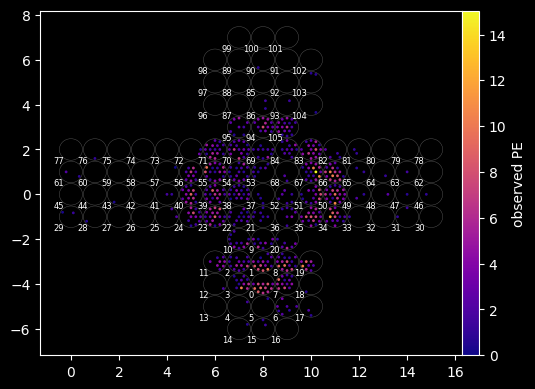

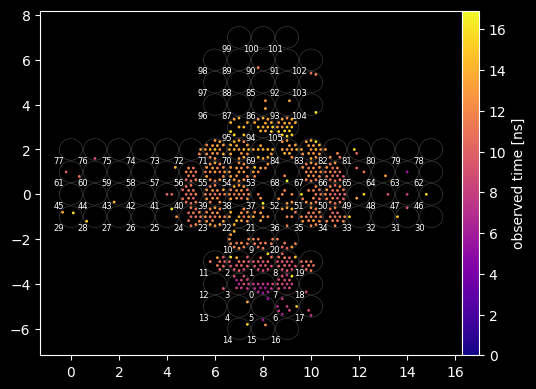

In [8]:
WCSIM_EVENT_INDEX = 0
wcsim_event = wcsim_events[WCSIM_EVENT_INDEX]
wcsim_prepared = wcsim_fitter.prepare_event(wcsim_event)

print(wcsim_prepared)
print(f'prompt window: {wcsim_prepared.prompt_min_ns:.1f} to '
      f'{wcsim_prepared.prompt_max_ns:.1f} ns')
print(f'hits:          {wcsim_event.n_hits} digitized -> '
      f'{wcsim_prepared.n_hit_pmts} active PMTs with prompt charge')

plot_event(wcsim_prepared, quantity='observed_pe')
plot_event(wcsim_prepared, quantity='observed_time');

## 5. WCSim: fit the event

Setup is done, so this cell times the fit and nothing else. Compare it with the setup time from section 3a: the difference is the point of separating them. Later events fitted with the same `wcsim_fitter` cost roughly the same as this one.

The current production fitter does **not** use Minuit. Its `minuit_valid` batch-output field is a historical compatibility alias, so the summary below reports the real track-aligned optimizer, finite/accepted status, objective evaluations, retained seed candidates, optimized basins, candidate failures, history records, and wall time.

`mcs_status` reports what the multiple-scattering stage did. `applied` means a scattering stage produced a result; `not_requested` means MCS was off or routed to a stage this mode does not use; `not_applied` means it was requested and no stage produced a result. Only `failed_straight_fallback` indicates a failure, and even then the straight fit is retained.

In [9]:
fit_start = time.perf_counter()
wcsim_result = wcsim_fitter.fit(wcsim_event)
print(f'fit: {time.perf_counter() - fit_start:.1f} s '
      f'(setup was {wcsim_setup_wall:.1f} s and is not repeated)')

summarize_fit(wcsim_result)

fit: 84.9 s (setup was 8.6 s and is not repeated)


,value
minimum_valid,True
fit_accepted,True
objective_finite,True
fval,2127.578054
mcs_status,applied
mcs_applied,False
straight_fit_fval,2254.060378
optimizer,track_aligned_exact_joint_block_quadratic
total_objective_evaluations,172
fit_attempts,1


,estimate,error
parameter,,
x0,-10.521894,10.608043
y0,-0.597592,17.891430
z0,-1354.134516,5.117343
cx,-0.008308,0.004105
cy,0.003108,0.007588
cz,0.999961,0.000041
length,1134.870656,NaN
visible_length,1134.870656,NaN
full_range,1134.870656,20.005515


minimum_valid                                                         True
fit_accepted                                                          True
objective_finite                                                      True
fval                                                           2127.578054
mcs_status                                                         applied
mcs_applied                                                          False
straight_fit_fval                                              2254.060378
optimizer                        track_aligned_exact_joint_block_quadratic
total_objective_evaluations                                            172
fit_attempts                                                             1
optimized_basins                                                         1
seed_candidates_retained                                                 5
candidate_failures                                                       0
optimizer_history_records

### 5a. Compare the fit with the sample truth

A digitized NPZ already carries the primary particle's vertex, direction and energy, so a fit can be checked against them without the `AllSecondaries` ROOT. `wcsim_npz_primary_truth` reads those arrays and converts them into the fitter's frame using the driver's own rule, `x_detector = 10 * x_wcsim_cm + offset_mm`, where the WCTE offset is the prism y-centre. None of it is available to the likelihood.

Read the length row with care. `csda_range_mm` is the packaged table's electromagnetic CSDA distance down to the Cherenkov threshold, which is what a `full_length` fit estimates. WCSim muons travel slightly less far above threshold than that table predicts — about 8 mm at 200 MeV, 18 mm at 300 MeV and 27 mm at 400 MeV in the packaged calibration — so a small negative length residual is a convention difference rather than a fit bias. `apply_wcsim_visible_range_convention=True` applies that measured offset as a reporting-only correction over its 180–425 MeV domain; it never touches the likelihood and is never used for real WCTE data.

One event's residuals are not a bias measurement either. Fit quality is judged on the mean *and* the width of the residual distribution over an ensemble, which is a batch run's job.

In [ ]:
wcsim_truth = wcsim_npz_primary_truth(WCSIM_FILE, wcsim_event.source_index)

print(f"truth: {wcsim_truth['particle']} at "
      f"KE = {wcsim_truth['kinetic_energy_mev']:.1f} MeV, "
      f"CSDA range = {wcsim_truth['csda_range_mm']:.1f} mm")

truth_residuals(wcsim_result, wcsim_truth)

## 6. WCSim: post-cut PE and timing closure

`observed_pe` and `observed_time_ns` are exactly the PMT-aligned observables handed to the likelihood after the prompt and active-PMT cuts. `expected_pe` and `expected_time_ns` are evaluated at the final estimate using the selected production objective. The timing likelihood predicts a source-resolved first-arrival distribution rather than one scalar; `expected_time_ns` is its PMT-wise mean before zero-mean transit-time smearing. For charge-only fits these times are diagnostics and did not influence the minimum.

In [10]:
wcsim_result.pmt_table(hit_only=True).head(20)

,pmt_id,slot,pmt_position,pmt_x_mm,pmt_y_mm,pmt_z_mm,observed_pe,expected_pe,observed_time_ns,expected_time_ns,timing_used_in_fit,time_diagnostic_available
0,0,0,0,-5.480061e-14,-858.675,5.480061e-14,5.847404,5.077407,7.7,7.298914,True,True
1,1,0,1,-9.529665e+01,-872.917,3.996778e-14,8.562398,4.381659,7.3,7.352779,True,True
2,2,0,2,-4.764832e+01,-872.917,8.252932e+01,0.000000,2.298342,NaN,NaN,False,False
3,3,0,3,4.764832e+01,-872.917,8.252932e+01,0.000000,2.262511,NaN,NaN,False,False
4,4,0,4,9.529665e+01,-872.917,7.497881e-14,7.702624,4.261927,7.6,7.361331,True,True
5,5,0,5,4.764832e+01,-872.917,-8.252932e+01,9.138842,7.654048,6.5,7.057142,True,True
6,6,0,6,-4.764832e+01,-872.917,-8.252932e+01,6.999882,7.727837,5.7,7.053006,True,True
7,7,0,7,-1.822660e+02,-914.399,2.010624e-14,3.385355,2.766219,8.2,7.512402,True,True
8,8,0,8,-1.578470e+02,-914.399,9.113302e+01,0.000000,1.462282,NaN,NaN,False,False
9,9,0,9,-9.113302e+01,-914.399,1.578470e+02,0.000000,1.213321,NaN,NaN,False,False


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(wcsim_result.observed_pe, wcsim_result.expected_pe, s=8, alpha=0.7)
limit = max(wcsim_result.observed_pe.max(), wcsim_result.expected_pe.max(), 1.0)
axes[0].plot([0, limit], [0, limit], 'k--', linewidth=1)
axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
timed = wcsim_result.timing_comparison_mask
axes[1].scatter(
    wcsim_result.expected_time_ns[timed],
    wcsim_result.observed_time_ns[timed],
    s=8, alpha=0.7,
)
axes[1].set(xlabel='model first-arrival mean [ns]', ylabel='observed time [ns]')
fig.tight_layout()

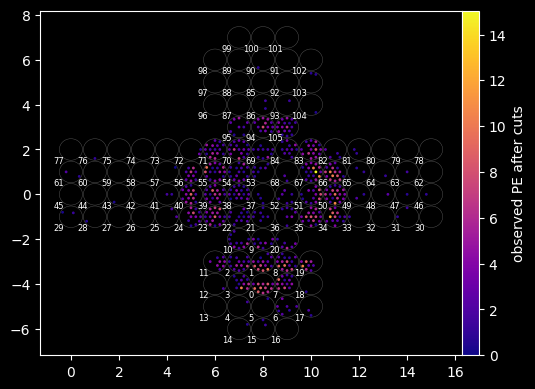

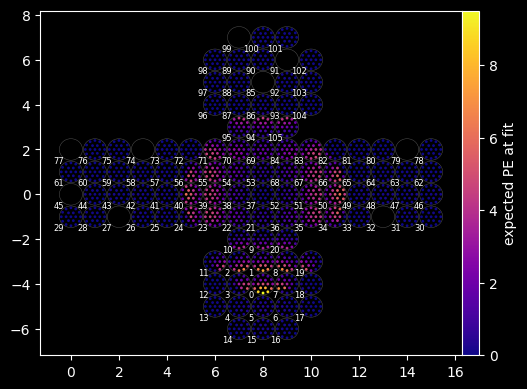

In [12]:
plot_event(wcsim_result, quantity='observed_pe', color_label='observed PE after cuts')
plot_event(wcsim_result, quantity='expected_pe', color_label='expected PE at fit');

# WCTE example

The same six steps as the WCSim section, with one addition: real data goes through collaboration event selection first, so there is a beam-PID policy to choose and a selection to inspect.

## 7. WCTE: choose the small set of settings that normally matters

This example obtains both events and the authoritative active-PMT list from run 2079. For a first interactive study, the important choices are the run, particle population/hypothesis, the two mode axes, the likelihood, the beam PID policy, the number of raw ROOT entries to scan, and the number of selected events to retain.

Keep the notebook configuration short unless the study genuinely requires an advanced change. Anything you leave out keeps the launcher default, and `changed_options()` below shows exactly what you moved away from it.

In [ ]:
wcte_config = WCTEConfig(
    run=2079,
    event_source='selection',
    good_pmt_source='run',
    particle_selection_label='pion',   # which beam population to select
    fit_particle='pion',               # which track hypothesis to fit
    seeding_mode='general',            # 'general' (detector-wide) or 'beam'
    interaction_mode='absorption',     # 'full_length' or 'absorption'
    likelihood_mode='charge_time',     # 'charge_only', 'charge_time', 'timing_only'
    light_particle_pid_mode='act_tof', # 'act_tof' (default), 'tof', or 'act'
    n_root_entries=2000,
    max_events_to_fit=20,
)
wcte_config

`particle_selection_label` and `fit_particle` are deliberately separate. The first chooses which beam population `analysis_tools` selects; the second chooses the track hypothesis LicketyFit fits. They are usually the same, but they do not have to be: LicketyFit has no electron track hypothesis, so an electron-selected sample has to be fitted under some other supported hypothesis and interpreted accordingly.

Alternative authoritative PMT/event combinations are configured exactly as in `run_wcte.py`:

- user events + run mask: `event_source='file'`, `user_event_file=...`, `good_pmt_source='run'`, `run=...`;
- collaboration-selected events + user mask: `event_source='selection'`, `good_pmt_source='file'`, `good_pmt_file=...`;
- user events + user mask: set both sources to `'file'`.

For real WCTE data, the user/run list is the complete authoritative active set. The historical WCSim inactive-slot list is never applied.

### 7a. Read back what the mode axes actually selected

Exactly as in section 2a, for the WCTE configuration.

In [ ]:
pd.Series(wcte_config.describe(), name='value').to_frame()

### 7b. WCTE beam PID: `light_particle_pid_mode`

This applies to nominal electron, muon, and pion samples. Proton selection stays on the run's `proton_tof_cut`, and kaons still need `selection_mode='custom'` with explicit cuts.

| mode | electron | muon | pion |
|---|---|---|---|
| `act_tof` (default) | ACT e-veto above its cut, TOF below the e/mu boundary | ACT e-veto below its cut, ACT tagger above its cut, TOF between e/mu and mu/pi | ACT e-veto below, ACT tagger below, TOF between mu/pi and the proton cut |
| `tof` | TOF below e/mu | TOF between e/mu and mu/pi | TOF between mu/pi and the proton cut |
| `act` | legacy ACT electron cut, optional fast-particle TOF veto | legacy ACT muon cuts, optional veto | legacy ACT pion cuts, optional veto |

The two TOF boundaries are **resolved per ROOT input**, not fixed numbers. LicketyFit uses explicit production scalars when a production writes them, and otherwise solves for the equal-density crossing between the run's adjacent calibrated Gaussian populations (`tof_mean_*`, `tof_std_*`). A boundary is accepted only if the means are ordered and the densities cross between them. It never substitutes a midpoint, because that would assign a confident particle label to an unresolved population.

`act_tof` is an intersection, so it accepts fewer events than `act` in exchange for purity. When a boundary cannot be defined, `act_tof` degrades for that boundary only: it keeps ACT identity plus every remaining valid TOF cut, prints one fallback notice, and records the reason in metadata. `tof` has no ACT identity to fall back on, so it stops with an error instead.

Two consequences worth internalising before you use this in an analysis:

- **Boundaries are not transferable between runs or momenta.** The overrides `electron_muon_tof_boundary_override_ns` and `muon_pion_tof_boundary_override_ns` exist for a separately validated calibration, not for copying one run's number onto another. Both are recorded in metadata when used.
- **These are selection counts, not purity measurements.** The TOF populations used to build the boundaries are themselves derived from beam-monitor classifications. `WCTE_PID_SELECTION.md` has the validation numbers for r1775, r2079, and r1855 and the caveats that come with them.

## 8. WCTE: load a small selected-event collection

The call below uses the same `analysis_tools` DataLoader/BeamSelection adapter as the batch driver. `n_root_entries` limits raw entries inspected; `max_events_to_fit` limits events retained after selection. This step does not initialize the optical fitter yet.

In [ ]:
wcte_fitter = SingleEventFitter(wcte_config)
wcte_events = wcte_fitter.load_events()
wcte_events

In [ ]:
pd.DataFrame([
    {
        'selected_index': i,
        'root_entry': event.metadata.get('source_root_entry_index'),
        'event_id': event.metadata.get('source_event_id'),
        'raw_hits': event.n_hits,
        'raw_charge_adc': event.total_charge,
    }
    for i, event in enumerate(wcte_events)
])

### 8a. What the PID policy actually did to this sample

`selection_summary()` reports the requested mode, the mode applied to this population, the boundaries this run resolved and where each came from, whether the per-boundary ACT fallback fired, and the cut list handed to `BeamSelection`.

A boundary of `None` means it was not usable for this run. That is a legitimate outcome, and it is not a value to copy into another run's override. `light_particle_pid_mode_applied` of `None` means the selected sample is not a nominal light-particle population, so the policy did not apply to it at all.

In [ ]:
summary = wcte_fitter.selection_summary()
display(pd.Series(
    {k: v for k, v in summary.items() if k != 'selection_cut_specs'},
    name='value',
).to_frame())

print('Cuts applied by BeamSelection:')
for branch, operator, value in summary['selection_cut_specs']:
    print(f'  {branch} {operator} {value}')

### 8b. Warm up the WCTE fitter -- again, this cell is not the fit

A second fitter needs its own setup: a separate engine, its own seed bank, and its own proxy library, because its configuration digest differs from the WCSim one. Some compiled kernels are shared with the fitter in section 3a, so this is usually quicker than that one was.

In [ ]:
print('One-time setup for the WCTE fitter. This is NOT the fit.')

setup_start = time.perf_counter()
wcte_fitter.initialize()
wcte_setup_wall = time.perf_counter() - setup_start

print(f'\nfitter setup finished in {wcte_setup_wall:.1f} s')
print('Every event fitted with this fitter now reuses it.')

## 9. WCTE: select an event and display it as the fitter sees it

As in section 4, `prepare_event` applies the prompt-time window, the active-PMT mask, ADC-to-PE conversion, the relative-efficiency treatment and the event time-reference shift, then stops. For real WCTE data the raw readout window is thousands of nanoseconds wide, so the unfiltered record on the commented line below looks far busier than the event really is.

Section 8b has already paid the setup cost, so this step is only per-event preparation and should be quick.

In [ ]:
WCTE_EVENT_INDEX = 19
wcte_event = wcte_events[WCTE_EVENT_INDEX]
wcte_prepared = wcte_fitter.prepare_event(wcte_event)

meta = wcte_prepared.metadata
print(wcte_prepared)
print(f"prompt window:      {wcte_prepared.prompt_min_ns:.2f} to "
      f"{wcte_prepared.prompt_max_ns:.2f} ns, in the event-relative reference")
print(f"time offset removed: {meta.get('global_time_offset_ns', float('nan')):.2f} ns")
print(f"hits:                {meta.get('raw_hit_count')} loaded -> "
      f"{meta.get('prompt_hit_count')} inside the prompt window and on an active PMT")

plot_event(wcte_prepared, quantity='observed_pe', log_scale=True)
plot_event(wcte_prepared, quantity='observed_time');

# For comparison, the unfiltered loader output before any of the above:
# plot_event(wcte_event, quantity='charge', color_label='selected charge [ADC]', log_scale=True)

### 9a. The prompt window is a setting

Which hits survive is controlled by a few options, and they are the first thing to check if a display looks wrong.

For **WCTE**, `prompt_window_mode` defaults to `'peak_relative'`. `'fixed'` requires both `prompt_time_min_ns` and `prompt_time_max_ns` — that is how the 0–17 ns validation analyses are reproduced — and `'none'` disables the cut. `time_reference_mode` (default `'beam_corrected_peak'`) sets the zero point that `observed_time_ns` and the prompt bounds are measured from, and the offset it removed is recorded so you can get back to input times.

For **WCSim**, leaving `prompt_time_min_ns` and `prompt_time_max_ns` as `None` keeps the production peak-relative selection: find the primary prompt peak within `primary_prompt_peak_search_max_ns` (default 100 ns), then keep hits from 0 to peak + 5 ns. The search bound matters because a digitized readout window can be thousands of nanoseconds wide, and without it a later unrelated pulse can be picked as the primary peak. The hit data alone cannot tell you what that later pulse was.

Setting both bounds on either source gives a deliberately fixed window instead.

## 10. WCTE: fit the selected event

Setup is already done, so this cell times the fit and nothing else. The output columns are the same ones described in section 5.

In [ ]:
fit_start = time.perf_counter()
wcte_result = wcte_fitter.fit(wcte_event)
print(f'fit: {time.perf_counter() - fit_start:.1f} s '
      f'(setup was {wcte_setup_wall:.1f} s and is not repeated)')

summarize_fit(wcte_result)

## 11. WCTE: inspect post-cut PE and timing closure

The same comparison as section 6. WCTE times are in the fitted event-relative reference; the removed input-time offset is stored in `wcte_result.raw_result['global_time_offset_ns']`. The expected values additionally include geometry clipping, charge normalization, and any selected explicit mPMT-boundary subclass.

In [ ]:
wcte_pmt_table = wcte_result.pmt_table(hit_only=True)
wcte_pmt_table.head(20)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(wcte_result.observed_pe, wcte_result.expected_pe, s=8, alpha=0.7)
limit = max(wcte_result.observed_pe.max(), wcte_result.expected_pe.max(), 1.0)
axes[0].plot([0, limit], [0, limit], 'k--', linewidth=1)
axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
timed = wcte_result.timing_comparison_mask
axes[1].scatter(
    wcte_result.expected_time_ns[timed],
    wcte_result.observed_time_ns[timed],
    s=8, alpha=0.7,
)
axes[1].set(xlabel='expected time [ns]', ylabel='observed time [ns]')
fig.tight_layout()

In [ ]:
vmin = 0.1
vmax = 7
plot_event(wcte_result, quantity='observed_pe', color_label='observed PE after cuts', log_scale=True, vmin=vmin, vmax=vmax)
plot_event(wcte_result, quantity='expected_pe', color_label='expected PE at fit', log_scale=True, vmin=vmin, vmax=vmax);

To fit another already-loaded event, only the event-specific preparation and fit are repeated:

```python
next_result = wcte_fitter.fit(wcte_events[1])
summarize_fit(next_result)
```

# The settings you will actually change

The cells below construct configurations and read back their resolved routing. None of them fit anything, so they run instantly and are safe to experiment with. Every setting shown has the same name in the launcher.

## 12. Likelihood and physics switches

`likelihood_mode` is `charge_only`, `charge_time`, or `timing_only`. The four physics switches are independent and default to the validated all-physics configuration:

| switch | default | what it adds |
|---|---|---|
| `enable_delta_electrons` | `True` | secondary-electron light along the track |
| `enable_mcs` | `True` | master switch for multiple scattering, routed to one mode-specific implementation |
| `enable_reflection` | `True` | blacksheet reflection; always in first-arrival timing, charge inclusion is fixed by the light-yield policy |
| `enable_photon_scattering` | `True` | molecular scattering transport |

Turning a physics process off is a diagnostic, not a speed setting to leave off by accident. Photon scattering is the expensive one.

Some combinations are genuinely unsupported rather than merely unusual, and the resolver rejects them up front. The two you are most likely to hit are shown below: general-mode navigation reads hit timing so it cannot help a charge-only fit, and every general-mode MCS continuation needs charge so it cannot run in a timing-only fit.

In [ ]:
def routing(**overrides):
    "Resolve a WCSim configuration variant and report it, or report why it was rejected."
    try:
        resolved = WCSimConfig(input_file=str(WCSIM_FILE), **overrides).reconstruction()
    except ValueError as error:
        return {'result': f'rejected: {error}'}
    return {
        'engine': resolved.internal_engine_mode,
        'likelihood': resolved.likelihood_mode,
        'navigation': resolved.navigation_mode,
        'primary_mcs (beam/absorption only)': resolved.primary_mcs_model,
        'cosmic_mcs (general+full_length only)': resolved.effective_cosmic_mcs_continuation,
    }

for label, overrides in [
    ('default (general + full_length)', {}),
    ('beam + full_length', dict(seeding_mode='beam', interaction_mode='full_length')),
    ('general + absorption', dict(seeding_mode='general', interaction_mode='absorption')),
    ('charge_only, seeding left on', dict(likelihood_mode='charge_only')),
    ('charge_only, seeding off', dict(likelihood_mode='charge_only',
                                      cosmic_multilateration_seed_mode='off')),
    ('timing_only, MCS left on', dict(likelihood_mode='timing_only')),
    ('timing_only, MCS off', dict(likelihood_mode='timing_only',
                                  cosmic_mcs_continuation='off',
                                  cosmic_multilateration_seed_mode='off')),
    ('enable_mcs=False', dict(enable_mcs=False)),
]:
    print(f'--- {label}')
    for key, value in routing(**overrides).items():
        print(f'    {key}: {value}')

## 13. Constraining coordinates with `fixed_parameters`

`fixed_parameters` fixes physical track coordinates exactly. Which keys are legal depends on the mode pair, because the modes do not share a longitudinal coordinate:

| keys | where they are valid |
|---|---|
| `x0_mm`, `y0_mm`, `z0_mm`, `direction`, `t0_ns` | every mode |
| `length_mm` | `full_length`, either seeding mode |
| `full_range_mm`, `kinetic_energy_mev` | `general` + `full_length`, and both `absorption` pairs |
| `visible_length_mm` | `absorption` only |

`length_mm`, `full_range_mm`, and `kinetic_energy_mev` name the same coordinate in `general` + `full_length`, so supply exactly one. `direction` is fixed as one complete vector and normalized automatically — individual components cannot be fixed separately without breaking the unit-vector constraint.

Use this to isolate a question. Fixing the vertex and direction turns a track fit into a pure range/energy scan; fixing the energy tests whether a length bias is coming from the longitudinal coordinate or from the geometry.

In [ ]:
for label, fixed in [
    ('vertex fixed', {'x0_mm': 0.0, 'y0_mm': 0.0, 'z0_mm': -1348.0}),
    ('direction fixed', {'direction': (0.0, 0.0, 1.0)}),
    ('energy fixed', {'kinetic_energy_mev': 300.0}),
    ('two aliases for one coordinate', {'length_mm': 1171.0, 'kinetic_energy_mev': 300.0}),
    ('absorption-only key in full_length', {'visible_length_mm': 1100.0}),
]:
    try:
        WCSimConfig(input_file=str(WCSIM_FILE), fixed_parameters=fixed).validate(check_paths=False)
        print(f'accepted  {label}: {fixed}')
    except ValueError as error:
        print(f'rejected  {label}: {error}')

## 14. Absolute light yield versus shape-only

`use_absolute_light_yield=False` profiles each event's overall light normalization out and fits the charge *shape* only. `True` keeps absolute light and automatically selects the calibrated threshold-censored compound-SPE likelihood. This is the one switch that moves between the two policies; `charge_likelihood` only applies when absolute light is off.

The defaults differ by data source, which is deliberate:

| | WCSim | WCTE |
|---|---|---|
| `use_absolute_light_yield` | `True` | `False` |
| `absolute_light_yield_source` | `wcsim_calibration` or `mathematical` | `measured` or `mathematical` |
| default manifest | `wcsim_muon_absolute_light_direct_shape_v3.json` | none — you supply one |

The WCSim `mathematical` estimate intentionally preserves both QE boosts present in the audited WCSim source. The WCTE one deliberately does not apply them, because real data is not WCSim. A WCSim manifest is rejected for WCTE and vice versa: a WCTE manifest is calibrated *after* the active-PMT mask, ADC-to-PE conversion, geometry, and per-mPMT efficiency correction, so it is specific to that detector and run context.

Turning absolute light on for WCTE without supplying a manifest is an error rather than a silent fallback:

In [ ]:
try:
    WCTEConfig(use_absolute_light_yield=True).validate(check_paths=True)
except ValueError as error:
    print('rejected:', error)

# Either supply your own calibrated manifest, or select the packaged ground-up estimate.
WCTEConfig(use_absolute_light_yield=True,
           absolute_light_yield_source='mathematical').validate(check_paths=True)
print('accepted: packaged mathematical WCTE manifest')

## 15. WCTE real-data preparation

These settings describe how raw WCTE data becomes fitter observables. They rarely need changing, but they are worth knowing because they change what the likelihood sees.

| setting | default | notes |
|---|---|---|
| `relative_efficiency_mode` | `'slot'` | per-slot data/MC ratio curves; `'type'` is the older per-mPMT-type behaviour, `'none'` disables the correction |
| `geometry_placement` | `'est'` | surveyed placement; `'design'` uses nominal coordinates. An active PMT with no surveyed placement falls back to design and the fallback is recorded |
| `charge_adc_per_pe` | `143.0` | ADC-to-PE conversion for real data |
| `prompt_window_mode` | `'peak_relative'` | `'fixed'` requires both `prompt_time_min_ns` and `prompt_time_max_ns`, e.g. the 0–17 ns validation window |
| `time_reference_mode` | `'beam_corrected_peak'` | established real-data timing reference |
| `apply_mpmt_data_quality_cuts` etc. | `True` | event-level DQ predicates, applied before beam PID |
| `extra_selection_cuts` | `()` | `(branch, operator, value)` triples; appended in nominal mode, the complete selection in custom mode |

`selection_mode='custom'` with explicit `extra_selection_cuts` is how you select a population `analysis_tools` has no nominal definition for — kaons, for instance, require it.

## 16. Performance and what this notebook does differently

The single-event layer forces serial execution and suppresses batch checkpointing, because one interactive fit runs in the notebook process. It changes execution mechanics only: the loader, detector, physics, seed bank, and objective are identical to a batch run.

For batch runs, the settings that matter are `nproc` (independent event workers), `max_internal_threads_per_worker` (bounds each worker's internal thread team so parallel workers do not oversubscribe), `n_events_per_batch`, and `warm_fit_kernels`. On a cold native cache, `auto_bootstrap_runtime_cache` runs one disposable fit first; the first compilation is both slow and numerically different from a cache-loaded process, so let it finish before starting production.

`continue_after_event_failure=True` saves a failed event as an explicit rejected row and continues. Set it `False` when debugging, where stopping at the first exception is more useful. `retain_straight_on_mcs_failure=True` keeps a valid straight fit when only the optional coherent-MCS stage fails.

For batch runs `auto_bootstrap_runtime_cache=True` does the same job as `scripts/warm_up_cache.py`: it runs one disposable fit in its own process before production starts, because the first execution of a freshly compiled kernel can be both slow and numerically different from a cache-loaded one. The notebook layer does not launch subprocesses, which is why the warm-up there is a separate script you run yourself. `runtime_cache_dir` (WCSim) and the `LF_RUNTIME_CACHE_DIR` environment variable point that cache somewhere persistent.

## What to transfer back to a batch run

Once an event study is satisfactory, copy the corresponding configuration values into `scripts/run_wcte.py` or `scripts/run_wcsim.py`. `changed_options()` lists exactly what you moved away from the launcher defaults, which is the set of lines to edit:

```python
wcte_config.changed_options()
```

Do not transfer notebook-only mechanics: single-event execution is always serial, does not create batch checkpoints, and keeps detailed diagnostics in memory rather than writing a batch output dictionary. Before a long run, `python3 scripts/run_wcte.py --check` validates the edited file and its explicit local paths without fitting anything, and `--show-config` prints the driver environment it would produce.